# AnalyzeTCSPC
Step-by-step TCSPC-FLIM analysis: IRF correction, per-pixel mean-arrival-time lifetime map (`tav`), false-colour image, decay fitting, phasor.

Run cells **in order**. Edit the **Parameters** cell for each experiment.

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, 'X:/FLIM_2026')
from FastFLIM_mod_AT0 import FastFLIM_mod_AT0
from flim_helpers import uplowthresh, Fit_decay, Calc_Phasor_Mat, phasor_ref_correction


## Helper functions
`uplowthresh` finds upper/lower display thresholds from the pixel histogram.
`Fit_decay` fits a multi-exponential model to the spatially-averaged decay.
`Calc_Phasor_Mat` computes phasor components and the density matrix.

## Parameters & data loading
Edit the analysis parameters, then run the cell — two file dialogs will open (IRF first, then data).
Set `dim_data` / `dim_irf` to match your TIFF axis order if needed.

| Variable | Shape | Description |
|----------|-------|-------------|
| `DataTCSPC` | `(ny, nx, nbin)` | TCSPC photon counts after reorder |
| `IRF` | `(nbin,)` | Instrument Response Function (summed to 1-D) |
| `sumTCSPC` | `(ny, nx)` | Total photons per pixel |
| `maskPMT` | `(ny, nx)` | 1 = valid pixel (counts > threshold), NaN = masked |

In [ ]:
import tkinter as tk
from tkinter import filedialog
import tifffile

# ── analysis parameters  (edit per experiment) ────────────────────────────────
Tcycle    = 12.5      # laser repetition period (ns)  -- 80 MHz -> 12.5 ns
threshold = 3         # minimum photon count per pixel (inclusive: >= threshold)
newFolder = 'X:/FLIM_2026/results'
FName     = 'sample01'
limits    = np.array([np.nan, np.nan])   # [lo, hi] ns  -- np.nan = auto
szPhs     = 0.005    # phasor histogram bin width (1/szPhs bins per axis, e.g. 200)
szBin     = 3        # spatial binning for phasor (1 = none, 3 = 3x3 pixels summed)

os.makedirs(newFolder, exist_ok=True)

# ── TIFF dimension order  (edit if your files differ) ─────────────────────────
# Axes: T = TCSPC time bins, Y = rows, X = columns
# Extra axes (Z, C, …) are summed away automatically.
# Common values:
#   'TYX'  -> (nbin, ny, nx)   <- most FLIM acquisition software
#   'YXT'  -> (ny, nx, nbin)
#   'TZYX' -> (nbin, nz, ny, nx)
dim_data = 'TYX'   # dimension order of the DataTCSPC TIFF
dim_irf  = 'TYX'   # dimension order of the IRF TIFF  (use 'T' if it is already 1-D)

# ── file picker ───────────────────────────────────────────────────────────────
def _pick(title):
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    p = filedialog.askopenfilename(
        title=title,
        filetypes=[('TIFF files', '*.tif *.tiff'), ('All files', '*.*')])
    root.destroy()
    return p or None

print('Select IRF TIFF  (dialog opening...)')
irf_path  = _pick('Select IRF TIFF')
print(f'  IRF:  {irf_path}')

print('Select DataTCSPC TIFF  (dialog opening...)')
data_path = _pick('Select DataTCSPC TIFF')
print(f'  Data: {data_path}')

# ── load ──────────────────────────────────────────────────────────────────────
IRF_raw  = tifffile.imread(irf_path).astype(float)
data_raw = tifffile.imread(data_path).astype(float)
print(f'\nRaw IRF  shape: {IRF_raw.shape}  dtype: {IRF_raw.dtype}')
print(f'Raw Data shape: {data_raw.shape}  dtype: {data_raw.dtype}')

# ── reorder to (ny, nx, nbin) ─────────────────────────────────────────────────
def _to_yxt(arr, order):
    """Transpose arr to (ny, nx, nbin). Non-TYX axes are summed first."""
    order = list(order.upper())
    extra = [i for i, c in enumerate(order) if c not in ('T', 'Y', 'X')]
    if extra:
        arr   = arr.sum(axis=tuple(sorted(extra)))
        order = [c for c in order if c in ('T', 'Y', 'X')]
    y, x, t = order.index('Y'), order.index('X'), order.index('T')
    return np.transpose(arr, [y, x, t])

DataTCSPC = _to_yxt(data_raw, dim_data)

if any(c in dim_irf.upper() for c in ('Y', 'X')):
    IRF = _to_yxt(IRF_raw, dim_irf).sum(axis=(0, 1))   # spatial IRF -> 1-D
else:
    IRF = IRF_raw.ravel()

# ── derived arrays needed by downstream cells ─────────────────────────────────
sumTCSPC = DataTCSPC.sum(axis=2)              # (ny, nx) total photons per pixel
maskPMT  = (sumTCSPC >= threshold).astype(float)
maskPMT[maskPMT == 0] = np.nan                # NaN = invalid pixel

print(f'\nDataTCSPC : {DataTCSPC.shape}  (ny, nx, nbin)')
print(f'IRF       : {IRF.shape}  (nbin,)')
print(f'sumTCSPC  : {sumTCSPC.shape}   range [{sumTCSPC.min():.0f}, {sumTCSPC.max():.0f}]')
print(f'maskPMT   : {np.isfinite(maskPMT).sum():.0f} valid pixels  (>= {threshold} photons)')

# ── display thresholds from percentiles ───────────────────────────────────────
_flat   = sumTCSPC.ravel()
_flat   = _flat[_flat > 0]
lo_pct  = np.percentile(_flat, 1)
hi_pct  = np.percentile(_flat, 99.9)
print(f'Display range:  lo (1st pct) = {lo_pct:.0f},  hi (99.9th pct) = {hi_pct:.0f}')

# # ── photon-count histogram ────────────────────────────────────────────────────
# fig_h, ax_h = plt.subplots(figsize=(8, 4))
# ax_h.hist(_flat, bins=200, color='steelblue', log=True)
# ax_h.axvline(lo_pct, color='orange', linewidth=1.5, linestyle='--',
#              label=f'1st pct  = {lo_pct:.0f}')
# ax_h.axvline(hi_pct, color='red',    linewidth=1.5, linestyle='--',
#              label=f'99.9th pct = {hi_pct:.0f}')
# ax_h.set_xlabel('photon count')
# ax_h.set_ylabel('pixel count (log)')
# ax_h.set_title(f'sumTCSPC histogram  [{FName}]')
# ax_h.legend()
# plt.tight_layout()
# plt.show()

# ── display ───────────────────────────────────────────────────────────────────
nbin_d   = DataTCSPC.shape[2]
dt_disp  = Tcycle / nbin_d
tau_disp = np.arange(nbin_d) * dt_disp       # rough time axis for display

decay    = DataTCSPC.sum(axis=(0, 1)).astype(float)   # spatially-averaged decay
irf_disp = IRF[:nbin_d] / IRF[:nbin_d].max()
decay_n  = decay / decay.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- intensity image clipped to percentile range ------------------------------
im = axes[0].imshow(sumTCSPC, cmap='inferno', aspect='equal', origin='upper',
                    vmin=lo_pct, vmax=hi_pct)
axes[0].set_title(f'Intensity  [{FName}]', fontsize=12)
axes[0].set_xlabel('x / px'); axes[0].set_ylabel('y / px')
cb = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
cb.set_label('photon count')

# -- spatially-averaged decay + IRF on log scale -----------------------------
axes[1].semilogy(tau_disp, decay_n, color='steelblue', linewidth=1.2, label='Data')
axes[1].semilogy(tau_disp, irf_disp, color='k', linewidth=0.8,
                 linestyle='--', label='IRF')
axes[1].set_xlabel('time / ns'); axes[1].set_ylabel('intensity (norm.)')
axes[1].set_title('Spatially-averaged decay', fontsize=12)
axes[1].set_xlim(0, Tcycle); axes[1].set_ylim(5e-3, 1.3)
axes[1].legend()

plt.suptitle(f'{data_path}', fontsize=9, y=1.01)
plt.tight_layout()
plt.show()


## Step 1-2: Mask preparation
Converts `maskPMT` (NaN or 0 = invalid) to a binary mask, and builds `maskTCSPC` (pixels above the photon-count threshold = 1).

In [ ]:
maskPMT = np.array(maskPMT, dtype=float)

if np.any(np.isnan(maskPMT)):
    mask = (~np.isnan(maskPMT)).astype(float)
else:
    mask = maskPMT.copy()
    maskPMT[maskPMT == 0] = np.nan

maskTCSPC = sumTCSPC.copy().astype(float)
maskTCSPC[np.isnan(maskTCSPC)]    = 0
maskTCSPC[maskTCSPC < threshold]  = 0
maskTCSPC[maskTCSPC >= threshold] = 1

fig, ax = plt.subplots(figsize=(5, 4))
imMask = ax.imshow(maskTCSPC, cmap='inferno', aspect='equal', origin='upper')
ax.set_title('MaskedImage')
cb = plt.colorbar(imMask, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(f'photon threshold = {threshold}')
plt.show()

print(f'Valid pixels (PMT mask):        {mask.sum():.0f}')
print(f'Valid pixels (>= {threshold} photons): {maskTCSPC.sum():.0f}')


## Step 3: IRF preprocessing
1. Sum over spatial dims to get a 1-D IRF trace.
2. **Circular right-shift by 2 bins** (same as MATLAB `[IRF2(end-1:end); IRF2(1:end-2)]`).
3. Subtract median of last 25 bins (background) and clip negatives.

In [ ]:
IRF2 = IRF.sum(axis=tuple(range(IRF.ndim - 1))) if IRF.ndim > 1 else IRF.copy()
IRF2 = IRF2.ravel().astype(float)
Ix   = len(IRF2)

# IRF2 = np.roll(IRF2, 2)           # 2-bin right-shift -- legacy from old instrument, not needed
IRF2 = IRF2 - np.median(IRF2[-25:]) # subtract background (median of last 25 bins)
IRF2 = IRF2 + np.abs(IRF2.min())    # clip negatives to zero

print(f'IRF bins (Ix): {Ix}')
print(f'IRF peak at bin {np.argmax(IRF2)},  max = {IRF2.max():.1f}')


## Step 4: Bin alignment
Compares the number of time bins in the data vs the IRF and resolves the mismatch:
- **IRF has more bins** -> average the IRF down to `nbin` data bins.
- **Data has more bins** -> reshape extra bins as repetitions (becomes 4th dimension).

In [6]:
# ── Bin alignment -- not needed for new instrument (nbin_data == Ix assumed) ──
# nbin_data = DataTCSPC.shape[2]
# nbin      = min(nbin_data, Ix)
#
# if nbin < Ix:
#     nrep = int(Ix // nbin)
#     IRF2 = IRF2[:nbin * nrep].reshape(nrep, nbin).mean(axis=0)
#     print(f'IRF averaged: {Ix} -> {nbin} bins  (nrep={nrep})')
# else:
#     nbin   = Ix
#     nx_d, ny_d = DataTCSPC.shape[0], DataTCSPC.shape[1]
#     nrep   = int(nbin_data // nbin)
#     DataTCSPC = DataTCSPC[:, :, :nbin * nrep]
#     DataTCSPC = DataTCSPC.reshape(nx_d, ny_d, nrep, nbin).swapaxes(2, 3)
#     print(f'Data reshaped: {nbin_data} -> ({nbin} bins x {nrep} reps)')
#
# print(f'nbin = {nbin},  DataTCSPC shape = {DataTCSPC.shape}')


In [ ]:
## Step 4b: Peak realignment
# Circularly shifts DataTCSPC and IRF2 so both peaks land at 8% of nbin.

# ── bin count check ───────────────────────────────────────────────────────────
import warnings
nbin_data = DataTCSPC.shape[2]
if nbin_data != Ix:
    warnings.warn(
        f'Bin count mismatch: DataTCSPC has {nbin_data} bins, IRF has {Ix} bins. '
        'Check dim_data / dim_irf — bin alignment (code-06) may need re-enabling.',
        RuntimeWarning, stacklevel=2)
nbin = nbin_data
dt   = Tcycle / nbin
tau  = np.arange(1, nbin + 1) * dt
print(f'nbin = {nbin},  dt = {dt:.4f} ns')

# ── target frame: 8% of nbin ─────────────────────────────────────────────────
target = int(round(0.08 * nbin))
print(f'Target peak frame: {target} / {nbin}  ({100 * target / nbin:.1f}%)')

# ── pixel mask: pixels with >= threshold photons (consistent with all other masks)
maskPixel    = sumTCSPC >= threshold
decay_masked = DataTCSPC[maskPixel].sum(axis=0).astype(float)

# ── shift DataTCSPC so fluorescence peak → target frame ──────────────────────
peak_data  = int(np.argmax(decay_masked))
shift_data = target - peak_data
DataTCSPC  = np.roll(DataTCSPC, shift_data, axis=2)
print(f'Data  peak was frame {peak_data:3d},  shifted by {shift_data:+d}')

# ── shift IRF2 so its peak → target frame ─────────────────────────────────────
peak_irf  = int(np.argmax(IRF2))
shift_irf = target - peak_irf
IRF2      = np.roll(IRF2, shift_irf)
print(f'IRF   peak was frame {peak_irf:3d},  shifted by {shift_irf:+d}')

# ── sanity-check plot ─────────────────────────────────────────────────────────
_decay_aligned = DataTCSPC[maskPixel].sum(axis=0).astype(float)
_decay_n       = _decay_aligned / _decay_aligned.max()
_irf_n         = IRF2 / IRF2.max()

fig_align, ax_align = plt.subplots(figsize=(7, 4))
ax_align.semilogy(tau, _irf_n, '--k', linewidth=0.8, label='IRF')
ax_align.semilogy(tau, _decay_n, color='steelblue', linewidth=1.2,
                  label=f'Data (>={threshold} ph, {maskPixel.sum()} px)')
ax_align.axvline(tau[target], color='orange', linewidth=1, linestyle=':',
                 label=f'target  frame {target}')
ax_align.set_xlabel('time / ns')
ax_align.set_ylabel('intensity (norm.)')
ax_align.set_title(f'After realignment  [{FName}]')
ax_align.set_xlim(0, Tcycle)
ax_align.set_ylim(5e-3, 1.3)
ax_align.legend()
fig_align.tight_layout()
plt.show()


## Step 5-6: Circular shift, time axis, normalised traces
Shifts data by 2 bins (same as IRF), builds the time axis `tau`, and computes the normalised photon-per-bin traces used for alignment and fitting.

In [ ]:
# DataTCSPC = np.roll(DataTCSPC, 2, axis=2)   # 2-bin shift -- not needed for new instrument

dt  = Tcycle / nbin
tau = np.arange(1, nbin + 1) * dt               # time axis (ns)

# masked average decay (pixels >= threshold) -- consistent with maskPixel
tmp1 = DataTCSPC[maskPixel].sum(axis=0).astype(float)

tmp = tmp1 / tmp1.max()
irf = IRF2 / IRF2.max()

print(f'dt = {dt:.4f} ns,  tau: {tau[0]:.3f} to {tau[-1]:.3f} ns')
print(f'Total photons in masked area: {tmp1.sum():.0f}  ({maskPixel.sum()} pixels)')


## Step 7-8: Align IRF peak to data peak + decay plot
Shifts the IRF so its peak coincides with the data peak, then plots both on a semilog y-axis.

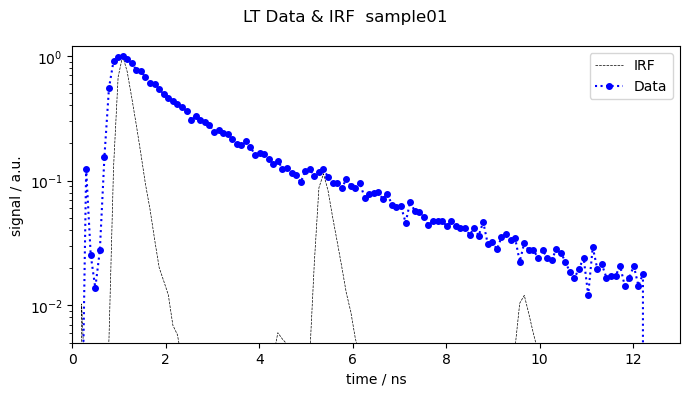

In [22]:
# ── IRF-to-data peak alignment (replaced by realignment cell -- kept for reference)
# xs1 = int(np.argmax(irf))
# xs2 = int(np.argmax(tmp))
# if xs1 > xs2:
#     shift = xs1 - xs2
#     irf   = np.concatenate([irf[shift:],   np.zeros(shift)])
#     IRF2  = np.concatenate([IRF2[shift:],  np.zeros(shift)])
#     print(f'IRF shifted left by {shift} bins')
# elif xs1 < xs2:
#     shift = xs2 - xs1
#     irf   = np.concatenate([np.zeros(shift), irf[:-shift]])
#     IRF2  = np.concatenate([np.zeros(shift), IRF2[:-shift]])
#     print(f'IRF shifted right by {shift} bins')
# else:
#     print('Peaks already aligned')

fig_lt, ax_lt = plt.subplots(figsize=(7, 4))
ax_lt.semilogy(tau, irf, '--k', linewidth=0.5, label='IRF')
ax_lt.semilogy(tau, tmp, ':o', markersize=4, markerfacecolor='b', color='b', label='Data')
ax_lt.set_ylabel('signal / a.u.')
ax_lt.set_xlabel('time / ns')
ax_lt.set_xlim(0, np.ceil(Tcycle))
ax_lt.set_ylim(5e-3, 1.2)
ax_lt.legend()
fig_lt.suptitle(f'LT Data & IRF  {FName}')
plt.tight_layout()
plt.show()


## Step 9: Apply count-threshold mask
Zeroes out pixels below `threshold` photon counts before the lifetime computation.

In [ ]:
bc = (slice(None), slice(None)) + (np.newaxis,) * (DataTCSPC.ndim - 2)
DataTCSPC = DataTCSPC * maskTCSPC[bc]
print(f'Pixels zeroed out: {(maskTCSPC == 0).sum():.0f}')

## Step 10: Core lifetime math -- mean arrival time
**Key equations:**
- `H = sum(tau * IRF) / sum(IRF)` -- mean arrival time of the IRF (instrument offset, scalar)
- `F[x,y] = sum(tau * data[x,y]) / sum(data[x,y])` -- mean photon arrival time per pixel
- `tav = F - H` -- fluorescence lifetime estimate per pixel (ns)

In [ ]:
DataTCSPC = DataTCSPC.astype(float)
if DataTCSPC.ndim == 3:
    DataTCSPC = DataTCSPC[:, :, :, np.newaxis]   # ensure 4-D

nx, ny, nbin, nch = DataTCSPC.shape
T = tau[np.newaxis, np.newaxis, :, np.newaxis]   # broadcast shape (1,1,nbin,1)

# H: mean arrival time of IRF (scalar instrument offset)
H = float(np.dot(tau, IRF2) / IRF2.sum())

# F: weighted mean arrival time per pixel  (nx, ny, nch)
F = (T * DataTCSPC).sum(axis=2) / DataTCSPC.sum(axis=2)
F = np.nan_to_num(F)

tag = DataTCSPC.sum(axis=2).squeeze()   # total photons  (nx, ny [, nch])
tav = (F - H).squeeze()                 # lifetime map   (nx, ny [, nch])
tav = np.clip(tav, 0, None)

print(f'H (IRF mean arrival time): {H:.4f} ns')
valid_tav = tav[maskPixel & (tav > 0)]
if valid_tav.size > 0:
    print(f'tav stats (masked) -- min: {valid_tav.min():.3f} ns,  '
          f'mean: {valid_tav.mean():.3f} ns,  max: {valid_tav.max():.3f} ns')

# ── quick tav image (masked to pixels >= threshold photons) ──────────────────
_tav_disp = tav.copy().astype(float)
_tav_disp[~maskPixel] = np.nan
_vmin, _vmax = np.nanpercentile(_tav_disp, 1), np.nanpercentile(_tav_disp, 99)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(_tav_disp, cmap='jet', aspect='equal', origin='upper',
               vmin=_vmin, vmax=_vmax)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('tav / ns')
ax.set_title(f'Mean arrival-time lifetime  [{FName}]', fontsize=11)
ax.set_xlabel('x / px'); ax.set_ylabel('y / px')
plt.tight_layout()
plt.show()


## Step 11: False-colour FLIM image
Auto-determines lifetime display range with `uplowthresh` (if `limits` is NaN), then calls `FastFLIM_mod_AT0` to generate and display the image.

In [ ]:
saveLTimg = os.path.join(newFolder, FName)
limits    = np.asarray(limits, dtype=float)

if np.all(np.isnan(limits)):
    ind = tag < threshold
    if not np.any(~ind):
        ind = tag < 1
    tim_auto = tav.copy()
    tim_auto[ind] = 0
    hi1, lo1 = uplowthresh(tim_auto, 0.85, 0.005)
    limits = np.array([lo1, hi1])
    print(f'Auto limits: [{limits[0]:.3f}, {limits[1]:.3f}] ns')

LTImg, Bar = FastFLIM_mod_AT0(saveLTimg, tag, tav, threshold, limits)

## Step 12: Exponential decay fitting
`Fit_decay` fits a multi-exponential model to the spatially-averaged decay `tmp1`:
1. Grid search over fractional IRF shift (-5 to +5 bins, step 0.5)
2. NNLS on amplitude distribution -> component groups -> initial lifetime guesses
3. Cascade Nelder-Mead optimization (10 cascades x 10 perturbations, shrinking spread)

The fitted model is overlaid on the IRF/data plot from Step 7-8.

In [ ]:
tau2, amp2, off2, z2, chi2_2, model2 = Fit_decay(IRF2, tmp1, Tcycle, dt)

# overlay fitted model on the decay plot from Step 7-8
peak = int(np.argmax(tmp))
if model2 is not None and model2.max() > 0:
    model2N = model2 / model2.max()
    ax_lt.semilogy(tau[peak:], model2N[peak:], 'g', linewidth=1.2, label='Fit_decay')
    ax_lt.legend()
    fig_lt.canvas.draw()

# amplitude-weighted lifetime
valid_mask = amp2 > 0
aw_LT2 = (float(np.dot(tau2[valid_mask], amp2[valid_mask]) / amp2[valid_mask].sum())
          if valid_mask.any() and amp2[valid_mask].sum() != 0 else np.nan)

# cap to 5 components for storage
tau2     = np.asarray(tau2).ravel()[:5]
amp2     = np.asarray(amp2).ravel()[:5]
tau_tmp2 = np.zeros(5); tau_tmp2[:len(tau2)] = tau2
amp_tmp2 = np.zeros(5); amp_tmp2[:len(amp2)] = amp2

print(f'Fit_decay:  chi2 = {chi2_2:.4f},  aw_LT = {aw_LT2:.4f} ns')
for i, (t_, a_) in enumerate(zip(tau2, amp2)):
    if a_ > 0:
        print(f'  Component {i+1}: tau = {t_:.4f} ns,  amp = {a_:.4f}')

## Step 13: Phasor analysis
Calls `Calc_Phasor_Mat` to compute the phasor components and density histogram.
Pass `IRF2` (the preprocessed IRF from Step 3) so the function can compute the correct instrument phase offset.

In [ ]:
fig_name0 = os.path.join(newFolder, FName + '_Phas.png')
try:
    S, G, M = Calc_Phasor_Mat(IRF2, DataTCSPC, Tcycle, dt, szPhs, fig_name0,
                               min_count=threshold, spatial_bin=szBin)
except Exception as e:
    print(f'Phasor failed: {e}')
    nbin3 = int(round(1.0 / szPhs)) + 1
    M = np.zeros((nbin3, nbin3))
    S = G = None

Phasor0 = M[::-1]
print(f'Phasor matrix shape: {Phasor0.shape}')
if S is not None:
    print(f'G range: [{np.nanmin(G):.3f}, {np.nanmax(G):.3f}]  '
          f'S range: [{np.nanmin(S):.3f}, {np.nanmax(S):.3f}]')

# ── Reference correction (uncomment when a reference standard is available) ───
# Load a separate TIFF of the reference fluorophore (e.g. Rhodamine 6G, tau ~4.08 ns)
# measured on the same instrument session, then:
#
# ref_raw  = tifffile.imread('path/to/reference.tif').astype(float)
# ref_data = _to_yxt(ref_raw, dim_data)
# S_ref, G_ref, _ = Calc_Phasor_Mat(IRF2, ref_data, Tcycle, dt, szPhs, None,
#                                    min_count=threshold, spatial_bin=szBin)
# tau_ref_ns = 4.08   # known lifetime of your reference fluorophore (ns)
# freq_mhz   = 1000.0 / Tcycle
# G_corr, S_corr, tau_mod, tau_phi = phasor_ref_correction(
#     G, S, G_ref, S_ref, tau_ref_ns, freq_mhz)


## Step 14: Lifetime summary metrics
Three independent scalar estimates derived from `tav`:
- **Tau_av** (Method 1): mean of PMT-masked pixels where `tav > H/2`
- **Tau_norm** (Method 3): mean photon arrival time in the whole signal area minus H
- **Tau_mask** (Method 4): mean tav after re-applying the PMT mask to the photon data

In [ ]:
# Method 1 -- mean tav of PMT-masked pixels where tav > H/2
Tau_1  = tav * maskPMT
valid  = Tau_1[Tau_1 > (H / 2)]
Tau_av = float(np.nanmean(valid)) if valid.size > 0 else np.nan

# Method 3 -- mean photon arrival time across signal area minus H
Tau_norm = float(np.dot(tau, tmp1) / tmp1.sum() - H)

# Method 4 -- tav mean after re-masking photon data with PMT mask
DT_masked = DataTCSPC * maskPMT[:, :, np.newaxis, np.newaxis]
F1        = np.nansum(T * DT_masked, axis=2) / np.nansum(DT_masked, axis=2)
tav2      = np.clip((F1 - H).squeeze(), 0, None)
Tau_mask  = float(np.nanmean(tav2))

print(f'Tau_av   (Method 1 -- PMT mask, tav > H/2):  {Tau_av:.4f} ns')
print(f'Tau_norm (Method 3 -- area mean - H):         {Tau_norm:.4f} ns')
print(f'Tau_mask (Method 4 -- PMT-masked tav mean):   {Tau_mask:.4f} ns')

## Save and collect results

In [ ]:
# save LT figure
fig_name1 = os.path.join(newFolder, FName + '_LT.png')
fig_lt.savefig(fig_name1)
print(f'LT figure saved: {fig_name1}')

# collect outputs
Dcays1   = {'ns': tau, 'irf_counts': IRF2}
Dcays2   = {'tmp1': tmp1, 'model': model2}
lifetime = {
    'Tau_av':   Tau_av,
    'Tau_mask': Tau_mask,
    'Tau_norm': Tau_norm,
    'tau_tmp2': tau_tmp2,
    'amp_tmp2': amp_tmp2,
    'aw_LT2':   aw_LT2,
    'chi2':     chi2_2,
}

print()
print('=== Lifetime summary ===')
for k, v in lifetime.items():
    print(f'  {k:12s}: {v}')